# Kou jump–diffusion lab

This notebook ties together:

1. **Normal vs double-exponential** density plots (`normal_de_density_plots.py`)
2. **Path simulation** (`KouProcess_paths.py`)
3. **European option pricing**: Hh series (symmetric Kou), Fourier / Gil–Pelaez (general), and **Monte Carlo** cross-check (`kou_jump_pricing.py`)

**Working directory:** run Jupyter with the notebook folder on `sys.path`, or execute the path cell below so imports resolve.

In [1]:
from pathlib import Path
import sys

NB_DIR = Path.cwd().resolve()
candidates = [NB_DIR, NB_DIR / "code" / "Process", NB_DIR.parent / "Process"]
for c in candidates:
    if (c / "kou_jump_pricing.py").is_file():
        sys.path.insert(0, str(c))
        print("Using Process path:", c)
        break
else:
    raise FileNotFoundError("Could not locate kou_jump_pricing.py; cd to project code/Process or ORIE project root.")

import matplotlib.pyplot as plt
import numpy as np

import normal_de_density_plots as nde
import KouProcess_paths as koup
import kou_jump_pricing as kpr

Using Process path: /Users/tyau/Desktop/cornell course/spring/ORIE 5610 Stochastic cal/project/code/Process


## 1. Densities: Normal vs Kou double-exponential

Default parameters match a **symmetric unit-variance** Laplace (`p=0.5`, `η₁=η₂=√2`). The next cell also overlays a mildly asymmetric choice.

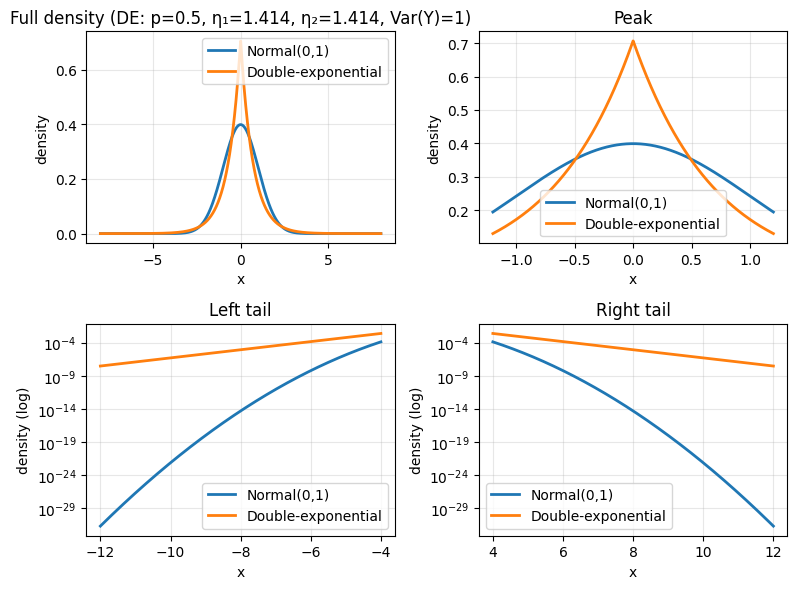

In [2]:
nde.plot_four_views(p=0.5, eta1=2 ** 0.5, eta2=2 ** 0.5, save_prefix=None, show=False)
plt.show()

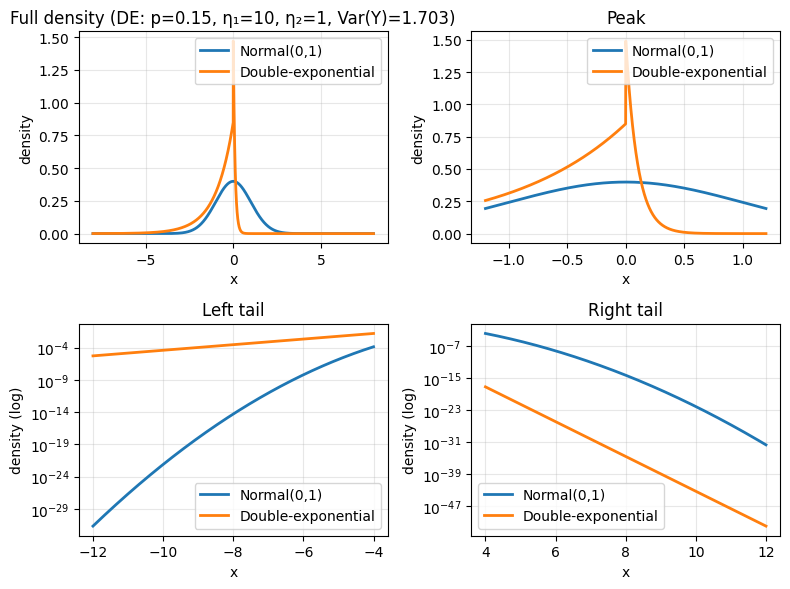

In [3]:
# Asymmetric example (shape / tail asymmetry demo)
'''
args:
p: probability of jump
eta1: jump size for negative jump
eta2: jump size for positive jump
'''
nde.plot_four_views(p=0.15, eta1=10.0, eta2=1.0, save_prefix=None, show=False)
plt.show()

## 2. Simulated Kou paths

Risk-neutral drift uses `ψ = E[e^Y]-1` with Kou jump sizes.

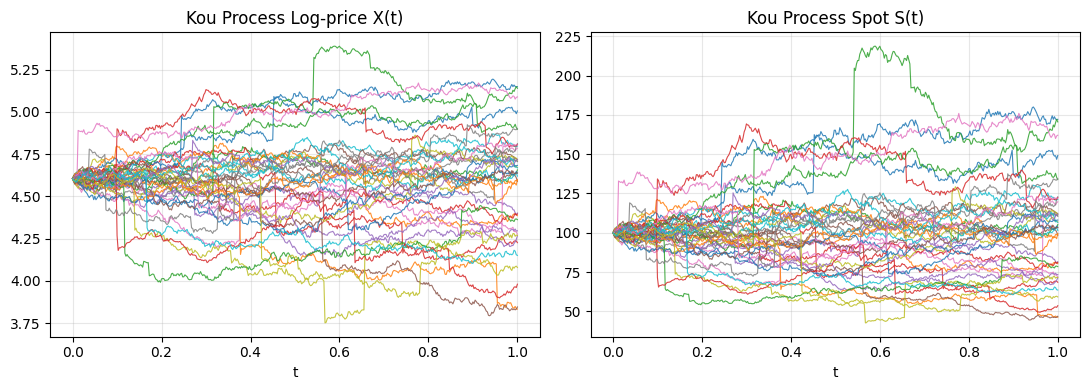

In [4]:
paths = koup.GeneratePathsKou(
    NoOfPaths=40,
    NoOfSteps=400,
    S0=100.0,
    T=1.0,
    r=0.05,
    sigma=0.2,
    lam=3.0,
    p=0.5,
    eta1=10.0,
    eta2=10.0,
)
tg = paths["time"]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(tg, paths["X"].T, lw=0.8, alpha=0.85)
ax[0].set_title("Kou Process Log-price X(t)")
ax[0].set_xlabel("t")
ax[0].grid(True, alpha=0.3)
ax[1].plot(tg, paths["S"].T, lw=0.8, alpha=0.85)
ax[1].set_title("Kou Process Spot S(t)")
ax[1].set_xlabel("t")
ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Option prices: Hh (symmetric), Fourier, Monte Carlo

- **Hh series** (`kou_jump_call_hh`): symmetric Kou only (`p=0.5`, `η₁=η₂`).
- **Fourier** (`kou_jump_call_fourier`): general parameters; matches Hh in the symmetric case and **Black–Scholes** when `λ=0`.
- **MC** (`kou_jump_call_mc`): terminal-time simulation; compare to closed form.

In [5]:
S0, K, T, r, sig = 100.0, 100.0, 0.5, 0.05, 0.15
lam, p, eta1, eta2 = 2.0, 0.5, 10.0, 10.0

cf = kpr.kou_jump_call_fourier(S0, K, T, r, sig, lam, p, eta1, eta2)
hh = kpr.kou_jump_call_hh(S0, K, T, r, sig, lam, p, eta1, eta2, N_terms=30)
mc = kpr.kou_jump_call_mc(S0, K, T, r, sig, lam, p, eta1, eta2, n_paths=250_000, seed=7)
bs = kpr.black_scholes_call(S0, K, T, r, sig)
cf0 = kpr.kou_jump_call_fourier(S0, K, T, r, sig, 0.0, p, eta1, eta2)

print(f"Fourier (Kou):     {cf:.6f}")
print(f"Hh series:         {hh:.6f}")
print(f"Monte Carlo:       {mc.price:.6f}  ± {1.96*mc.stderr:.6f} (95%)")
print(f"Black–Scholes:     {bs:.6f}")
print(f"Fourier (λ=0):    {cf0:.6f}  (should match BS)")
print(f"Put (Fourier):     {kpr.kou_jump_put_fourier(S0, K, T, r, sig, lam, p, eta1, eta2):.6f}")

Fourier (Kou):     7.751524
Hh series:         7.751524
Monte Carlo:       7.700474  ± 0.051755 (95%)
Black–Scholes:     5.527115
Fourier (λ=0):    5.527115  (should match BS)
Put (Fourier):     5.282515


In [6]:
# Asymmetric: Fourier vs MC (Hh not defined)
p2, e1, e2 = 0.4, 12.0, 8.0
cf2 = kpr.kou_jump_call_fourier(S0, K, T, r, sig, lam, p2, e1, e2)
mc2 = kpr.kou_jump_call_mc(S0, K, T, r, sig, lam, p2, e1, e2, n_paths=400_000, seed=11)
print(f"Asymmetric Fourier: {cf2:.6f}")
print(f"Asymmetric MC:      {mc2.price:.6f}  ± {1.96*mc2.stderr:.6f}")
print(f"Relative diff:       {abs(cf2 - mc2.price) / mc2.price * 100:.2f}%")

Asymmetric Fourier: 7.997643
Asymmetric MC:      8.026515  ± 0.036758
Relative diff:       0.36%


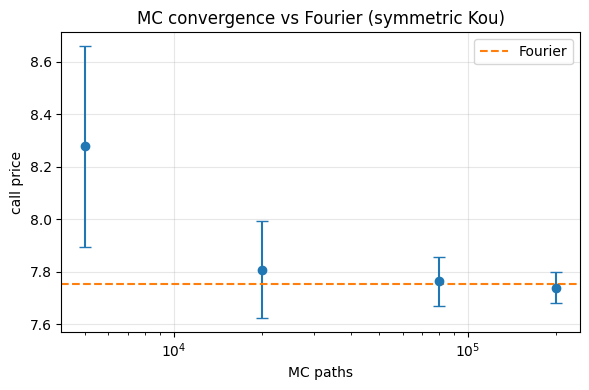

In [7]:
# MC standard error vs number of paths (symmetric Kou)
ns = np.array([5_000, 20_000, 80_000, 200_000], dtype=int)
errs, means = [], []
for n in ns:
    m = kpr.kou_jump_call_mc(S0, K, T, r, sig, lam, p, eta1, eta2, n_paths=int(n), seed=99)
    means.append(m.price)
    errs.append(1.96 * m.stderr)
plt.figure(figsize=(6, 4))
plt.errorbar(ns, means, yerr=errs, fmt="o", capsize=4)
plt.axhline(cf, color="C1", ls="--", label="Fourier")
plt.xscale("log")
plt.xlabel("MC paths")
plt.ylabel("call price")
plt.title("MC convergence vs Fourier (symmetric Kou)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()